# 필요 라이브러리

In [42]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import itertools
from joblib import Parallel, delayed
import statsmodels.api as sm

# 데이터 준비

In [43]:
start_date= "2001-01-01"
end_date= "2025-12-31"

In [44]:
ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=start_date, end=end_date)[0].copy()

# 인덱스를 월말 날짜로
ff.index = pd.to_datetime(ff.index.astype(str)) + pd.offsets.MonthEnd(0)
# % -> 소수
ff = ff / 100.0


C:\Users\USER\AppData\Local\Temp\ipykernel_5480\3546956132.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=start_date, end=end_date)[0].copy()
C:\Users\USER\AppData\Local\Temp\ipykernel_5480\3546956132.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=start_date, end=end_date)[0].copy()


In [45]:
ff.isnull().sum()

Mkt-RF    0
SMB       0
HML       0
RF        0
dtype: int64

In [46]:
fr = ff[["Mkt-RF", "SMB", "HML"]].copy()   # excess returns
rf = ff["RF"].copy()                     # risk-free

In [47]:
ff

,Mkt-RF,SMB,HML,RF
Date,,,,
2001-01-31,0.0325,0.0641,-0.0505,0.0054
2001-02-28,-0.1003,-0.0065,0.1223,0.0038
2001-03-31,-0.0725,0.0026,0.0647,0.0042
2001-04-30,0.0793,0.0050,-0.0464,0.0039
2001-05-31,0.0068,0.0248,0.0338,0.0032
...,...,...,...,...
2025-08-31,0.0184,0.0387,0.0442,0.0038
2025-09-30,0.0339,-0.0185,-0.0105,0.0033
2025-10-31,0.0196,-0.0055,-0.0309,0.0037


In [48]:
# 애플, 10년물, 원유, 달러인덱스
tickers = ['AAPL','^TNX','CL=F','DX-Y.NYB']
raw_data=yf.download(tickers,start=start_date,end=end_date)

C:\Users\USER\AppData\Local\Temp\ipykernel_5480\3346058167.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data=yf.download(tickers,start=start_date,end=end_date)
[*********************100%***********************]  4 of 4 completed


In [49]:
data=raw_data/100

In [50]:
data_month=data.resample('ME').last().dropna()#파마 프렌치 모형이랑 동일하게 월말로

In [51]:
data_month

Price          Close                                High                   \
Ticker          AAPL    CL=F DX-Y.NYB     ^TNX      AAPL    CL=F DX-Y.NYB   
Date                                                                        
2001-01-31  0.003240  0.2870   1.1052  0.05179  0.003371  0.2915   1.1118   
2001-02-28  0.002734  0.2742   1.1201  0.04908  0.002912  0.2820   1.1243   
2001-03-31  0.003306  0.2640   1.1737  0.04915  0.003404  0.2664   1.1763   
2001-04-30  0.003819  0.2846   1.1585  0.05338  0.004063  0.2899   1.1614   
2001-05-31  0.002989  0.2837   1.1907  0.05413  0.003032  0.2872   1.1929   
...              ...     ...      ...      ...       ...     ...      ...   
2025-08-31  2.316984  0.6401   0.9777  0.04227  2.329360  0.6455   0.9813   
2025-09-30  2.541456  0.6237   0.9777  0.04148  2.554331  0.6326   0.9805   
2025-10-31  2.698557  0.6098   0.9980  0.04101  2.767924  0.6138   0.9984   
2025-11-30  2.785893  0.5855   0.9946  0.04017  2.787392  0.5964   0.9982   
2025-12-31  2.728247  0.5795   0.9824  0.04130  2.738238  0.5847   0.9827   

Price                     Low                                Open          \
Ticker         ^TNX      AAPL    CL=F DX-Y.NYB     ^TNX      AAPL    CL=F   
Date                                                                        
2001-01-31  0.05196  0.003212  0.2825   1.1040  0.05167  0.003221  0.2900   
2001-02-28  0.04956  0.002715  0.2734   1.1170  0.04908  0.002903  0.2815   
2001-03-31  0.05121  0.003197  0.2596   1.1648  0.04878  0.003378  0.2645   
2001-04-30  0.05393  0.003726  0.2813   1.1547  0.05330  0.004000  0.2860   
2001-05-31  0.05481  0.002920  0.2755   1.1818  0.05409  0.002966  0.2805   
...             ...       ...     ...      ...      ...       ...     ...   
2025-08-31  0.04242  2.309298  0.6388   0.9769  0.04215  2.320677  0.6426   
2025-09-30  0.04152  2.526285  0.6203   0.9763  0.04106  2.543752  0.6314   
2025-10-31  0.04103  2.686480  0.5999   0.9942  0.04076  2.764631  0.6030   
2025-11-30  0.04036  2.757320  0.5827   0.9938  0.03990  2.770008  0.5858   
2025-12-31  0.04141  2.720255  0.5760   0.9794  0.04116  2.725550  0.5781   

Price                            Volume                         
Ticker     DX-Y.NYB     ^TNX       AAPL     CL=F DX-Y.NYB ^TNX  
Date                                                            
2001-01-31   1.1100  0.05179  7307048.0   856.59      0.0  0.0  
2001-02-28   1.1224  0.04924  5082336.0   823.64      0.0  0.0  
2001-03-31   1.1657  0.05007  4003496.0   639.47      0.0  0.0  
2001-04-30   1.1567  0.05330  4947768.0   402.23      0.0  0.0  
2001-05-31   1.1830  0.05481  4428928.0  1016.94      0.0  0.0  
...             ...      ...        ...      ...      ...  ...  
2025-08-31   0.9787  0.04228   394184.0     0.00      0.0  0.0  
2025-09-30   0.9791  0.04133   377043.0  2716.49      0.0  0.0  
2025-10-31   0.9949  0.04101   861671.0  2785.98      0.0  0.0  
2025-11-30   0.9957  0.03990   201356.0  1537.58      0.0  0.0  
2025-12-31   0.9801  0.04141   221396.0  1438.02      0.0  0.0  

[300 rows x 20 columns]

In [52]:
returns=pd.DataFrame()
returns['Oil']=data_month['Close']['CL=F'].pct_change()
returns['USD']=data_month['Close']['DX-Y.NYB'].pct_change()
returns['Yield']=data_month['Close']['^TNX'].diff()
returns.dropna(inplace=True)

## 비교 분석

In [53]:
def calculate_factor_risk_contribution(target, factors):
    X=sm.add_constant(factors)
    model=sm.OLS(target,X).fit()
    betas=model.params.drop('const')
    variance=np.var(target,ddof=1)
    contribution={}
    explained=0
    for i in factors.columns:
        component=betas[i]*factors[i]
        cov=np.cov(target,component)[0,1]
        contributions=(cov/variance)*100
        contribution[i]=contributions
        explained+=cov
    unexplainables=((variance - explained) / variance) * 100
    contribution['unexplainable']=unexplainables
    return contribution

In [54]:
target=data_month['Close']['AAPL'].pct_change()-rf
target=target.dropna()

In [55]:
fund=calculate_factor_risk_contribution(target,ff[1:])
macro_factors=pd.concat([returns,ff["Mkt-RF"]],axis=1).dropna()
macro=calculate_factor_risk_contribution(target,macro_factors)

In [56]:
df_risk=pd.DataFrame({
    "fundamental":pd.Series(fund),
    "Macro Model":pd.Series(macro)
}).fillna(0)

In [57]:
df_risk#시장요인이 있을 땐 둘 다 시장요인이 압도적임

,fundamental,Macro Model
HML,2.610319,0.000000
Mkt-RF,29.957117,32.082917
Oil,0.000000,1.314404
RF,-0.035757,0.000000
SMB,0.504864,0.000000
USD,0.000000,-1.294131
Yield,0.000000,-0.515037
unexplainable,66.963457,68.411847


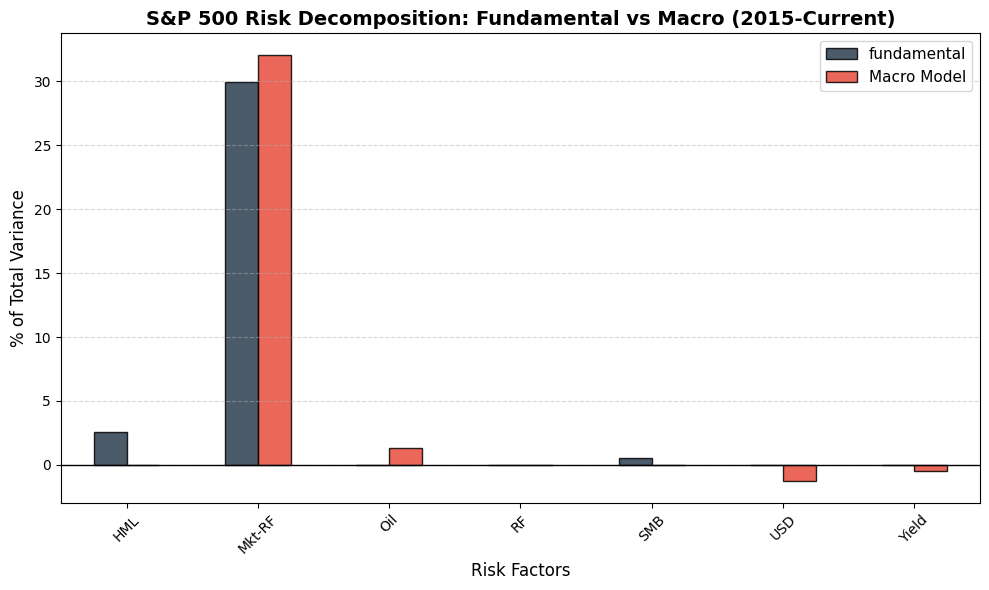

In [58]:
df_factor_only = df_risk.drop('unexplainable') # 순수 팩터 비교를 위해 고유 위험 제외

fig, ax = plt.subplots(figsize=(10, 6))
df_factor_only.plot(kind='bar', ax=ax, color=['#2c3e50', '#e74c3c'], alpha=0.85, edgecolor='black')

plt.title('S&P 500 Risk Decomposition: Fundamental vs Macro (2015-Current)', fontsize=14, fontweight='bold')
plt.ylabel('% of Total Variance', fontsize=12)
plt.xlabel('Risk Factors', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [59]:
fundamental=ff[["Mkt-RF","SMB", "HML"]]
fund=calculate_factor_risk_contribution(target,fundamental[1:])
# macro_factors=pd.concat([returns,ff["Mkt-RF"]],axis=1).dropna()
macro=calculate_factor_risk_contribution(target,returns)

In [60]:
df_risk_nomkt=pd.DataFrame({
    "fundamental":pd.Series(fund),
    "Macro Model":pd.Series(macro)
}).fillna(0)

In [61]:
df_risk_nomkt

,fundamental,Macro Model
HML,2.607668,0.000000
Mkt-RF,29.917481,0.000000
Oil,0.000000,3.380839
SMB,0.475778,0.000000
USD,0.000000,0.584820
Yield,0.000000,0.821844
unexplainable,66.999074,95.212497


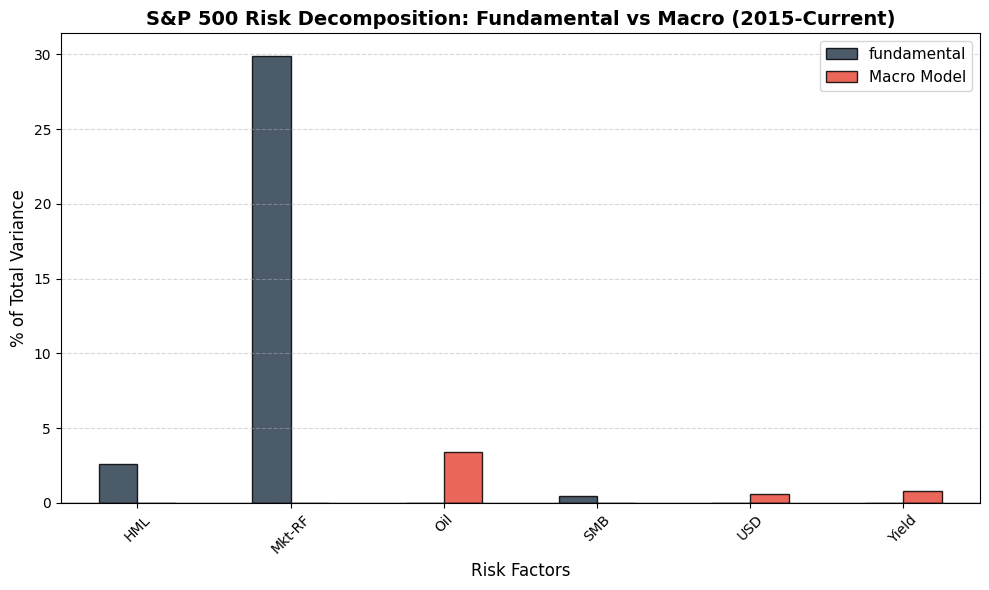

In [62]:
df_factor_only_nomkt = df_risk_nomkt.drop('unexplainable') 

fig, ax = plt.subplots(figsize=(10, 6))
df_factor_only_nomkt.plot(kind='bar', ax=ax, color=['#2c3e50', '#e74c3c'], alpha=0.85, edgecolor='black')

plt.title('S&P 500 Risk Decomposition: Fundamental vs Macro (2015-Current)', fontsize=14, fontweight='bold')
plt.ylabel('% of Total Variance', fontsize=12)
plt.xlabel('Risk Factors', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [63]:
fundamental=ff[["Mkt-RF","SMB", "HML"]]
fund=calculate_factor_risk_contribution(target,fundamental[1:])
# macro_factors=pd.concat([returns,ff["Mkt-RF"]],axis=1).dropna()
macro=calculate_factor_risk_contribution(target,returns)

In [64]:
df_risk=pd.DataFrame({
    "fundamental":pd.Series(fund),
    "Macro Model":pd.Series(macro)
}).fillna(0)

In [65]:
df_risk

,fundamental,Macro Model
HML,2.607668,0.000000
Mkt-RF,29.917481,0.000000
Oil,0.000000,3.380839
SMB,0.475778,0.000000
USD,0.000000,0.584820
Yield,0.000000,0.821844
unexplainable,66.999074,95.212497


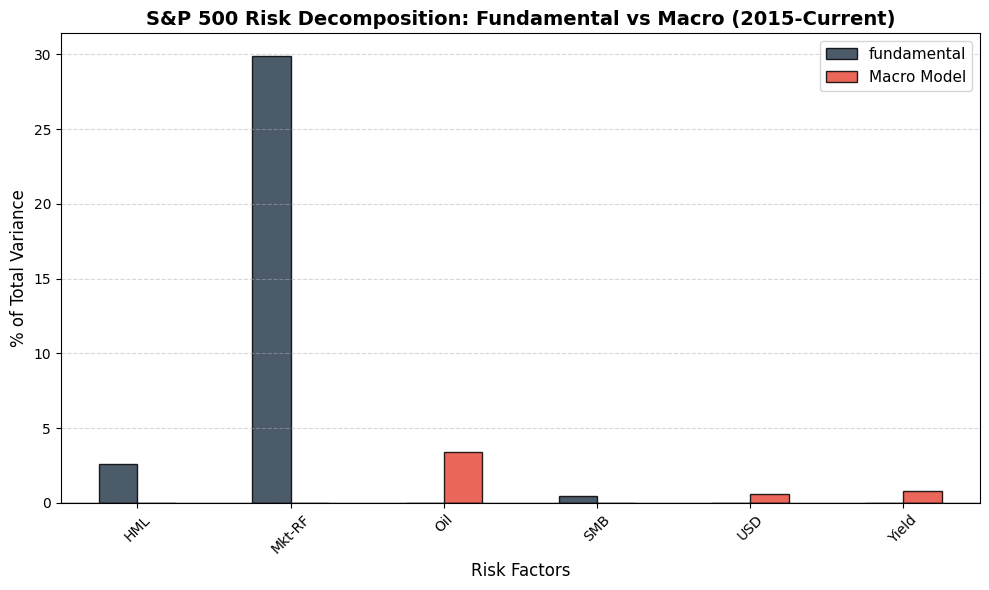

In [66]:
df_factor_only_nomkt = df_risk_nomkt.drop('unexplainable') # 순수 팩터 비교를 위해 고유 위험 제외

fig, ax = plt.subplots(figsize=(10, 6))
df_factor_only_nomkt.plot(kind='bar', ax=ax, color=['#2c3e50', '#e74c3c'], alpha=0.85, edgecolor='black')

plt.title('S&P 500 Risk Decomposition: Fundamental vs Macro (2015-Current)', fontsize=14, fontweight='bold')
plt.ylabel('% of Total Variance', fontsize=12)
plt.xlabel('Risk Factors', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 위 결과를 이용해서 회귀식 만들기

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     48.43
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.76e-25
Time:                        23:14:16   Log-Likelihood:                 335.05
No. Observations:                 299   AIC:                            -662.1
Df Residuals:                     295   BIC:                            -647.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0184      0.005      3.955      0.0

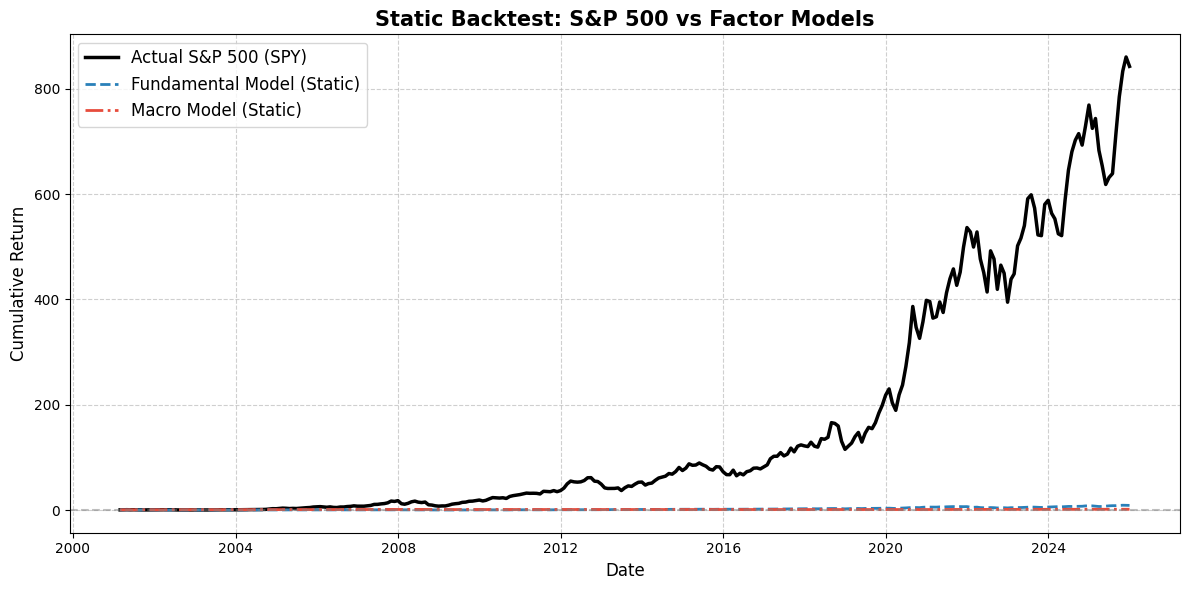

In [67]:
def get_static_betas(target, factors):
    X = sm.add_constant(factors)
    model = sm.OLS(target, X).fit()
    betas = model.params.drop('const')
    print(model.summary())
    return betas
fundamental_factors = ff[["Mkt-RF", "SMB", "HML"]]
common_idx = target.index.intersection(fundamental_factors.index).intersection(returns.index)
target_align = target.loc[common_idx]
fund_align = fundamental_factors.loc[common_idx]
macro_align = returns.loc[common_idx]
rf_align = rf.loc[common_idx]
beta_fund = get_static_betas(target_align, fund_align)
beta_macro = get_static_betas(target_align, macro_align)
print("--- Fundamental Model Betas ---")
print(beta_fund)
print("\n--- Macro Model Betas ---")
print(beta_macro)
model_fund_ret = (fund_align * beta_fund).sum(axis=1) + rf_align
model_macro_ret = (macro_align * beta_macro).sum(axis=1) + rf_align
actual_spy_ret = target_align + rf_align
cum_spy = (1 + actual_spy_ret).cumprod()
cum_fund = (1 + model_fund_ret).cumprod()
cum_macro = (1 + model_macro_ret).cumprod()



#백테스트 결과 시각화
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_spy.index, cum_spy, label='Actual S&P 500 (SPY)', color='black', linewidth=2.5)
ax.plot(cum_fund.index, cum_fund, label='Fundamental Model (Static)', color='#2980b9', linestyle='--', linewidth=2)
ax.plot(cum_macro.index, cum_macro, label='Macro Model (Static)', color='#e74c3c', linestyle='-.', linewidth=2)
ax.set_title('Static Backtest: S&P 500 vs Factor Models', fontsize=15, fontweight='bold')
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     9.438
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           0.000106
Time:                        23:14:16   Log-Likelihood:                 284.42
No. Observations:                 299   AIC:                            -562.8
Df Residuals:                     296   BIC:                            -551.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0258      0.005      4.744      0.0

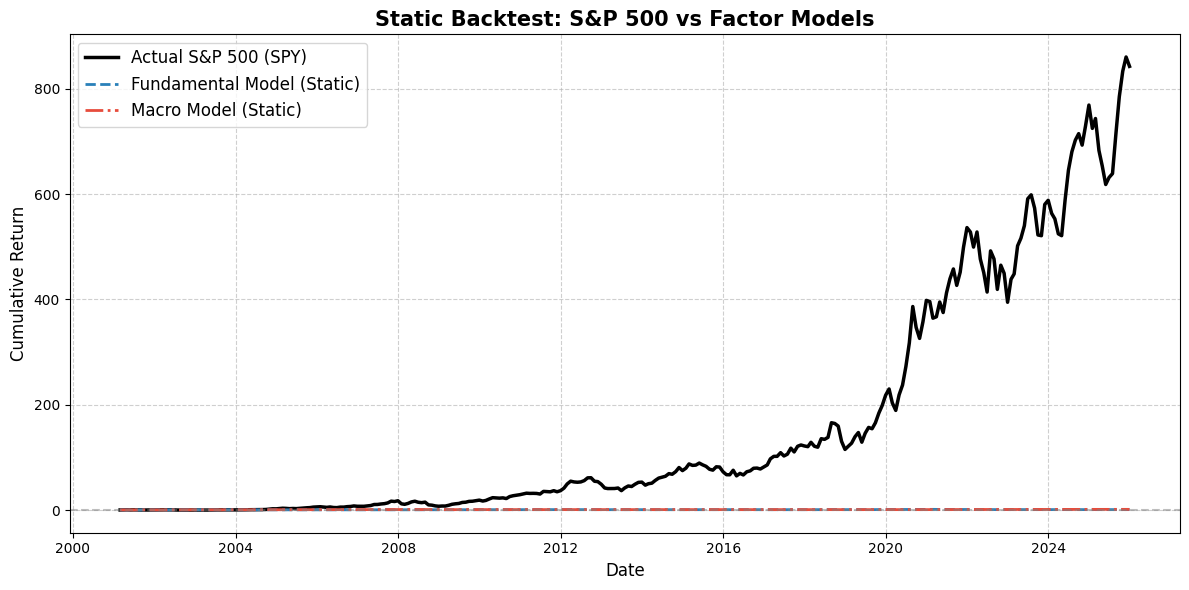

In [68]:
fundamental_factors = ff[[ "SMB", "HML"]]
common_idx = target.index.intersection(fundamental_factors.index).intersection(returns.index)
fund_align = fundamental_factors.loc[common_idx]
beta_fund = get_static_betas(target_align, fund_align)
beta_macro = get_static_betas(target_align, macro_align)
print("--- Fundamental Model Betas ---")
print(beta_fund)
print("\n--- Macro Model Betas ---")
print(beta_macro)
model_fund_ret = (fund_align * beta_fund).sum(axis=1) + rf_align
cum_fund = (1 + model_fund_ret).cumprod()



fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_spy.index, cum_spy, label='Actual S&P 500 (SPY)', color='black', linewidth=2.5)
ax.plot(cum_fund.index, cum_fund, label='Fundamental Model (Static)', color='#2980b9', linestyle='--', linewidth=2)
ax.plot(cum_macro.index, cum_macro, label='Macro Model (Static)', color='#e74c3c', linestyle='-.', linewidth=2)
ax.set_title('Static Backtest: S&P 500 vs Factor Models', fontsize=15, fontweight='bold')
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     72.69
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.08e-26
Time:                        23:14:16   Log-Likelihood:                 334.91
No. Observations:                 299   AIC:                            -663.8
Df Residuals:                     296   BIC:                            -652.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0184      0.005      3.954      0.0

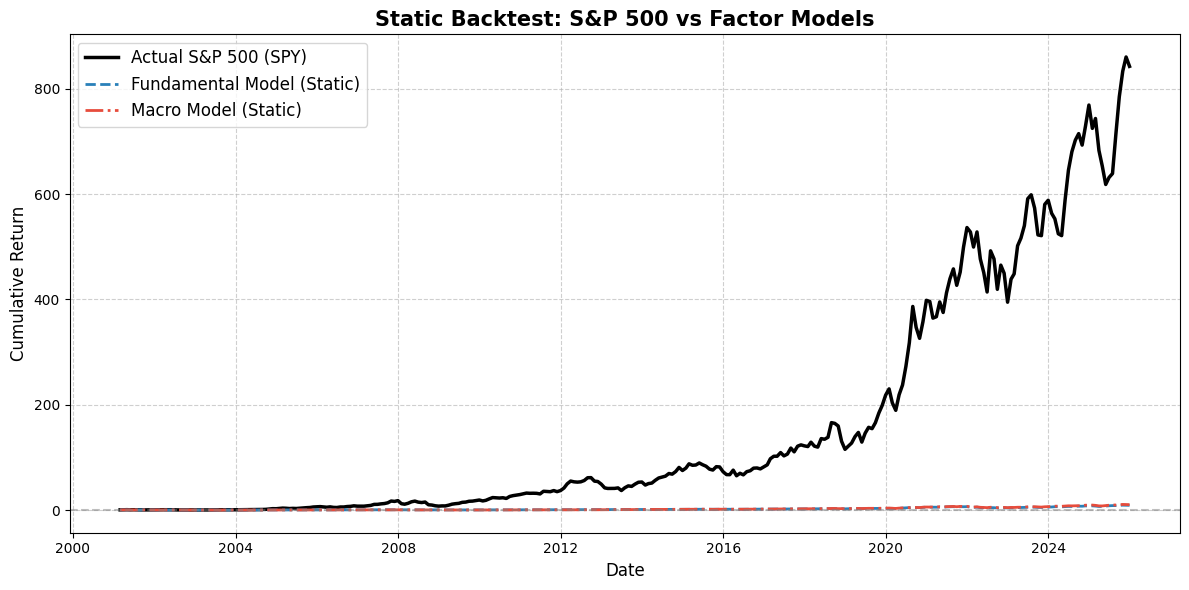

In [69]:
# fundamental_factors = ff[["Mkt-RF", "SMB", "HML"]]
fundamental_factors = ff[["Mkt-RF", "HML"]]
common_idx = target.index.intersection(fundamental_factors.index).intersection(returns.index)
fund_align = fundamental_factors.loc[common_idx]
# macro_align = pd.concat([returns.loc[common_idx], ff["Mkt-RF"].loc[common_idx]], axis=1)
macro_align = pd.concat([returns["USD"].loc[common_idx], ff[["Mkt-RF", "HML"]].loc[common_idx]], axis=1)
beta_fund = get_static_betas(target_align, fund_align)
beta_macro = get_static_betas(target_align, macro_align)
print("--- Fundamental Model Betas ---")
print(beta_fund)
print("\n--- Macro Model Betas ---")
print(beta_macro)
model_fund_ret = (fund_align * beta_fund).sum(axis=1) + rf_align
model_macro_ret = (macro_align * beta_macro).sum(axis=1) + rf_align
cum_fund = (1 + model_fund_ret).cumprod()
cum_macro = (1 + model_macro_ret).cumprod()



fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_spy.index, cum_spy, label='Actual S&P 500 (SPY)', color='black', linewidth=2.5)
ax.plot(cum_fund.index, cum_fund, label='Fundamental Model (Static)', color='#2980b9', linestyle='--', linewidth=2)
ax.plot(cum_macro.index, cum_macro, label='Macro Model (Static)', color='#e74c3c', linestyle='-.', linewidth=2)
ax.set_title('Static Backtest: S&P 500 vs Factor Models', fontsize=15, fontweight='bold')
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Economic Factor로 rollover해보면서 설명력 봐보기

In [70]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def check_stationarity(df, name="Data"):
    results = []
    for col in df.columns:
        # 결측치가 있으면 에러가 나므로 dropna() 처리 후 검정
        adf_result = adfuller(df[col].dropna())
        p_value = adf_result[1]
        
        # p-value가 0.05 미만이면 정상성(Stationary) 확보로 판단
        is_stationary = p_value < 0.05 
        
        results.append({
            'Variable': col,
            'p-value': round(p_value, 4),
            'Stationary': is_stationary
        })
    
    print(f"\n--- {name} 정상성 검정 결과 ---")
    display_df = pd.DataFrame(results)
    print(display_df)
    return display_df

# 데이터가 합쳐진 직후에 함수 실행
check_stationarity(target_adj, "Target (수익률)")
check_stationarity(macro_adj, "Macro (거시 요인)")
check_stationarity(fund_adj, "Fundamental (펀더멘털)")


--- Target (수익률) 정상성 검정 결과 ---
  Variable  p-value  Stationary
0     AAPL      0.0        True
1     AMZN      0.0        True
2     MSFT      0.0        True

--- Macro (거시 요인) 정상성 검정 결과 ---
  Variable  p-value  Stationary
0      Oil      0.0        True
1      USD      0.0        True
2    Yield      0.0        True

--- Fundamental (펀더멘털) 정상성 검정 결과 ---
  Variable  p-value  Stationary
0   Mkt-RF      0.0        True
1      SMB      0.0        True
2      HML      0.0        True
3      RMW      0.0        True
4      CMA      0.0        True


,Variable,p-value,Stationary
0,Mkt-RF,0.0,True
1,SMB,0.0,True
2,HML,0.0,True
3,RMW,0.0,True
4,CMA,0.0,True


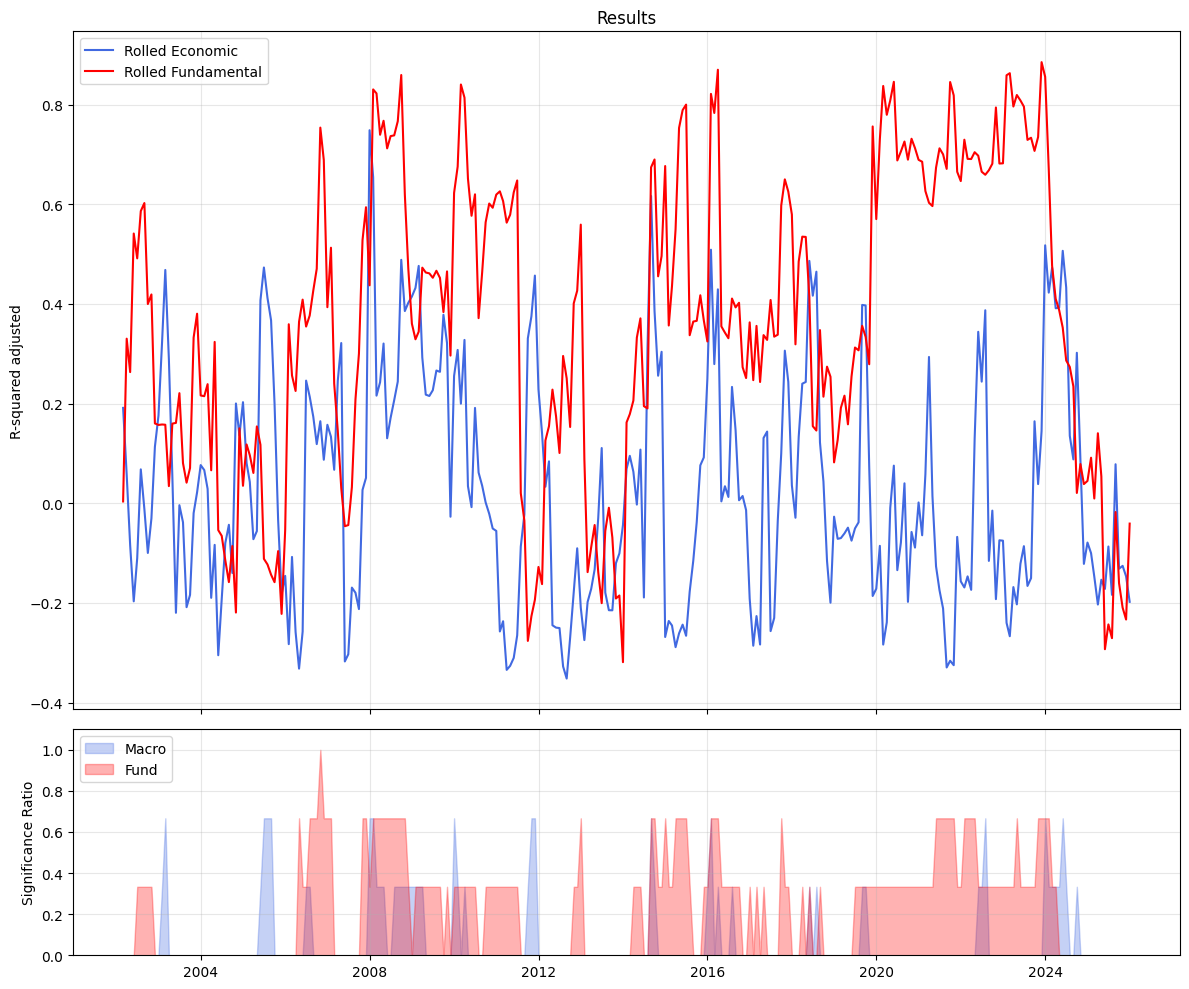

In [71]:
window_size=12
common_idx = target.index.intersection(fundamental.index).intersection(returns.index)
fund_adj = fundamental.loc[common_idx]
macro_adj = returns.loc[common_idx]
target_adj = target.loc[common_idx]
result_r2=[]
result_r2f=[]
result_r2f_noroll=[]
valid_m=[]
valid_f=[]
valid_fn=[]
def get_rsquared(target, factors):
    X = sm.add_constant(factors.values)
    model = sm.OLS(target.values, X).fit()
    p_values = model.pvalues[1:]
    valid=np.mean(p_values<0.05)
    return model.rsquared_adj,valid
for i in range(len(target)-window_size):
    start_index=i
    end_index=i+window_size
    target_rolled=target_adj.iloc[start_index+1:end_index+1]
    target_notrolled=target_adj.iloc[:end_index+1]
    fundamental_input=fund_adj.iloc[start_index+1:end_index+1]
    fundamental_no_roll=fund_adj.iloc[:end_index+1]
    macro_input=macro_adj.iloc[start_index:end_index]
    r2,vm=get_rsquared(target_rolled,macro_input)
    r2f,vf=get_rsquared(target_rolled,fundamental_input)
    r2f_no,vn=get_rsquared(target_notrolled,fundamental_no_roll)
    result_r2.append(r2)
    result_r2f.append(r2f)
    result_r2f_noroll.append(r2f_no)
    valid_m.append(vm)
    valid_f.append(vf)
    valid_fn.append(vn)
dates = target.index[window_size:] 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
# 상단 그래프: R-squared
ax1.plot(dates, result_r2, label='Rolled Economic', color='royalblue')
ax1.plot(dates, result_r2f, label='Rolled Fundamental', color='red')
# ax1.axhline(y=0.323, color='black', linestyle=':', label='Benchmark 0.323')
ax1.set_ylabel('R-squared adjusted')
ax1.set_title('Results')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 하단 그래프: 유의성 비율 (0~1 사이 값)
# 1에 가까울수록 모델 내 대부분의 변수가 통계적으로 유의함
ax2.fill_between(dates, valid_m, color='royalblue', alpha=0.3, label='Macro')
ax2.fill_between(dates, valid_f, color='red', alpha=0.3, label='Fund')
# ax2.fill_between(dates, valid_fn, color='green', alpha=0.3, label='Fund Significance')
ax2.set_ylabel('Significance Ratio')
ax2.set_ylim(0, 1.1)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# switching model 테스트 해보기

In [72]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import yfinance as yf

In [73]:
start_date = "2000-01-01"
end_date = "2025-12-31" 
tickers = ['AAPL', 'MSFT', 'AMZN']
raw_data_test = yf.download(tickers, start=start_date, end=end_date)
data_month_test = raw_data_test['Close'].resample('ME').last().dropna()
portfolio = data_month_test.pct_change().dropna()
portfolio.columns = ['AAPL', 'AMZN', 'MSFT'] 

C:\Users\USER\AppData\Local\Temp\ipykernel_5480\3922722255.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data_test = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed


In [74]:
def get_optimal_weights(mu, cov_matrix, target_return=0.0001):
    num_assets = len(mu)
    def objective_function(weights):
        return weights.T @ cov_matrix @ weights
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0},{'type': 'ineq', 'fun': lambda x: (x.T @ mu) -target_return})
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    init_guess = np.array(num_assets * [1. / num_assets])   
    result = sco.minimize(objective_function, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x
def get_rsquared(target_series, factors):
    X = sm.add_constant(factors.values)
    model = sm.OLS(target_series.values, X).fit()
    p_values = model.pvalues[1:]
    valid = np.mean(p_values < 0.05)
    return model.rsquared_adj, valid


In [104]:
window_size = 14
target = portfolio.copy()
target.index = pd.to_datetime(target.index.astype(str)).to_period('M')
fundamental.index = pd.to_datetime(fundamental.index.astype(str)).to_period('M')
returns.index = pd.to_datetime(returns.index.astype(str)).to_period('M')
common_idx = target.index.intersection(fundamental.index).intersection(returns.index)
fund_adj = fundamental.loc[common_idx]
macro_adj = returns.loc[common_idx]
target_adj = target.loc[common_idx]
target_adj.index = target_adj.index.to_timestamp('M')
fund_adj.index = fund_adj.index.to_timestamp('M')
macro_adj.index = macro_adj.index.to_timestamp('M')

In [105]:
weights_method1_dynamic = []
weights_method2_static = []

for i in range(len(target_adj) - window_size):
    start_index = i
    end_index = i + window_size
    Y_window = target_adj.iloc[start_index:end_index]
    macro_window = macro_adj.iloc[start_index:end_index]
    fund_window = fund_adj.iloc[start_index:end_index]
    
    # Y_notrolled = target_adj.iloc[:end_index]
    # fund_no_roll = fund_adj.iloc[:end_index]
    
    mu_m1 = []
    mu_m2 = []
    
    for col in target_adj.columns:
        y_col_rolled = Y_window[col]
        # y_col_notrolled = Y_notrolled[col]
        Y_train = y_col_rolled.iloc[1:]             
        X_macro_train = macro_window.iloc[:-1]      
        X_fund_train = fund_window.iloc[1:]        
        r2_m, _ = get_rsquared(Y_train, X_macro_train)
        r2_f, _ = get_rsquared(Y_train, X_fund_train)

        if r2_m > r2_f:
            model_m = sm.OLS(Y_train.values, sm.add_constant(X_macro_train.values)).fit()
            latest_macro = macro_window.iloc[-1].values 
            next_macro_factor = np.insert(np.atleast_1d(latest_macro), 0, 1.0)
            pred_1 = model_m.predict(next_macro_factor)[0]
        else:
            model_f = sm.OLS(Y_train.values, sm.add_constant(X_fund_train.values)).fit()
            betas = model_f.params
            expected_ff = fund_window.mean().values
            pred_1 = betas[0] + np.dot(betas[1:], expected_ff)
            
        mu_m1.append(pred_1) 
        # Y_train_no = y_col_notrolled.iloc[1:]
        # X_fund_train_no = fund_no_roll.iloc[1:]
        
        model_no = sm.OLS(Y_train.values, sm.add_constant(X_fund_train.values)).fit()
        betas_no = model_no.params
        expected_ff_no = fund_window.mean().values
        pred_2 = betas_no[0] + np.dot(betas_no[1:], expected_ff_no)
        
        mu_m2.append(pred_2)
    cov_matrix = Y_window.cov().values
    w_m1 = get_optimal_weights(np.array(mu_m1), cov_matrix)
    w_m2 = get_optimal_weights(np.array(mu_m2), cov_matrix)
    
    weights_method1_dynamic.append(w_m1)
    weights_method2_static.append(w_m2)


In [106]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

weights_macro_ts = []
weights_fund_ts = []

for i in range(len(target_adj) - window_size):
    start_index = i
    end_index = i + window_size
    
    Y_window = target_adj.iloc[start_index:end_index]
    macro_window = macro_adj.iloc[start_index:end_index]
    fund_window = fund_adj.iloc[start_index:end_index]
    
    mu_macro = []
    mu_fund = []
    
    for col in target_adj.columns:
        y_col_rolled = Y_window[col]
        
        # 종속 변수 (Y_t)
        Y_train = y_col_rolled.iloc[1:]             
        
        # 과거 수익률 변수 (Y_t-1) - 시계열(AR) 효과 반영
        Y_lag_train = y_col_rolled.iloc[:-1]        
        
        # 외생 변수 (X_t-1) - 거시 및 펀더멘털 모두 시차(Lag) 적용
        X_macro_train = macro_window.iloc[:-1]      
        X_fund_train = fund_window.iloc[:-1]        
        
        # ---------------------------------------------------------
        # 1. Macro 요인을 이용한 시계열 회귀 모형
        # ---------------------------------------------------------
        # 독립변수 묶기: [Y_t-1, Macro_t-1]
        X_m_combined = pd.concat([Y_lag_train, X_macro_train], axis=1)
        model_m = sm.OLS(Y_train.values, sm.add_constant(X_m_combined.values)).fit()
        
        # t+1 시점 예측을 위한 최신 데이터 (t 시점의 수익률과 거시지표)
        latest_y = y_col_rolled.iloc[-1]
        latest_macro = macro_window.iloc[-1].values 
        
        # 입력 데이터 형태 맞추기: [상수항, 최신 수익률, 최신 거시지표]
        next_macro_input = np.insert(latest_macro, 0, latest_y)
        next_macro_input = np.insert(next_macro_input, 0, 1.0)
        pred_macro = model_m.predict(next_macro_input)[0]
        mu_macro.append(pred_macro)
        
        # ---------------------------------------------------------
        # 2. Fundamental 요인을 이용한 시계열 회귀 모형
        # ---------------------------------------------------------
        # 독립변수 묶기: [Y_t-1, Fund_t-1]
        X_f_combined = pd.concat([Y_lag_train, X_fund_train], axis=1)
        model_f = sm.OLS(Y_train.values, sm.add_constant(X_f_combined.values)).fit()
        
        # t+1 시점 예측을 위한 최신 데이터 (t 시점의 수익률과 펀더멘털)
        latest_fund = fund_window.iloc[-1].values
        
        # 입력 데이터 형태 맞추기: [상수항, 최신 수익률, 최신 펀더멘털]
        next_fund_input = np.insert(latest_fund, 0, latest_y)
        next_fund_input = np.insert(next_fund_input, 0, 1.0)
        pred_fund = model_f.predict(next_fund_input)[0]
        mu_fund.append(pred_fund)
        
    cov_matrix = Y_window.cov().values
    
    # 각각 예측된 기대 수익률(mu)을 바탕으로 마코위츠 MVO 수행
    w_macro = get_optimal_weights(np.array(mu_macro), cov_matrix)
    w_fund = get_optimal_weights(np.array(mu_fund), cov_matrix)
    
    weights_macro_ts.append(w_macro)
    weights_fund_ts.append(w_fund)

=== 포트폴리오 성과 비교 ===
                    Method 1 (Dynamic)  Method 2 (Static)
Mean Return                   0.018251           0.018064
Variance                      0.004233           0.004254
Sharpe Ratio                  0.280510           0.276980
Max Drawdown (MDD)           -0.600623          -0.603923


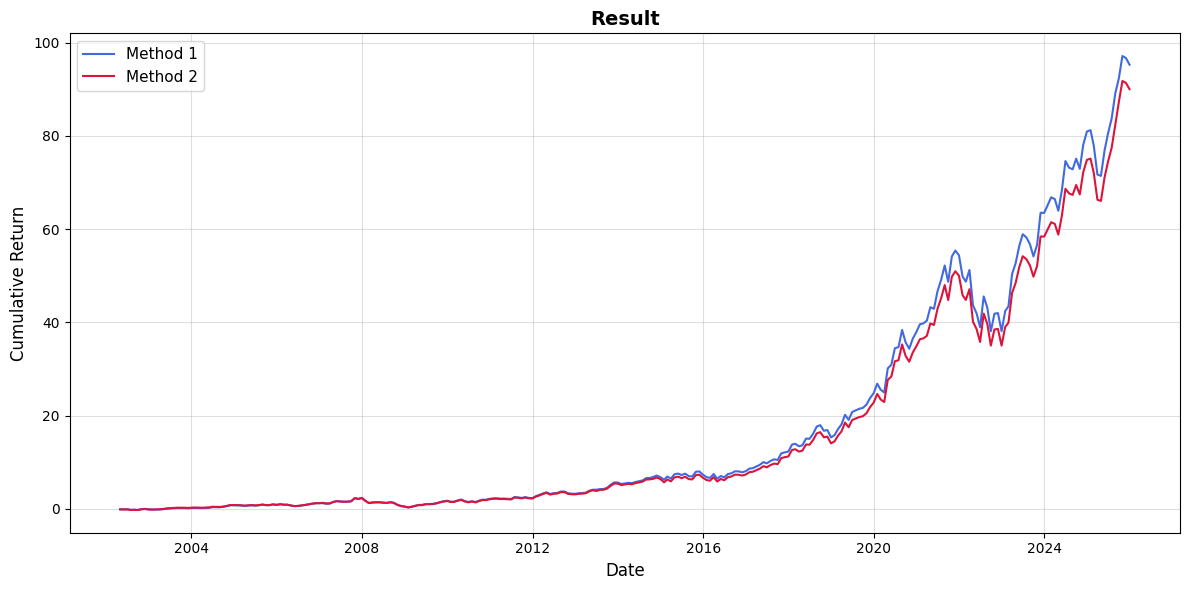

In [107]:
port_returns_m1 = []
port_returns_m2 = []

# 앞서 구한 1월 말 비중에 2월 실제 수익률을 곱해 진짜 성과를 확인
for i in range(len(weights_method1_dynamic)):
    actual_returns = target_adj.iloc[window_size + i].values
    
    ret_m1 = np.dot(weights_method1_dynamic[i], actual_returns)
    ret_m2 = np.dot(weights_method2_static[i], actual_returns)
    
    port_returns_m1.append(ret_m1)
    port_returns_m2.append(ret_m2)

port_returns_m1 = np.array(port_returns_m1)
port_returns_m2 = np.array(port_returns_m2)

def calculate_metrics(returns, risk_free_rate=0.0):
    mean_ret = np.mean(returns)
    var_ret = np.var(returns)
    std_ret = np.std(returns)
    
    sharpe_ratio = (mean_ret - risk_free_rate) / std_ret if std_ret != 0 else 0
    
    cum_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - running_max) / running_max
    mdd = np.min(drawdowns)
    
    return mean_ret, var_ret, sharpe_ratio, mdd

mean1, var1, sharpe1, mdd1 = calculate_metrics(port_returns_m1)
mean2, var2, sharpe2, mdd2 = calculate_metrics(port_returns_m2)

metrics_df = pd.DataFrame({
    'Method 1 (Dynamic)': [mean1, var1, sharpe1, mdd1],
    'Method 2 (Static)': [mean2, var2, sharpe2, mdd2]
}, index=['Mean Return', 'Variance', 'Sharpe Ratio', 'Max Drawdown (MDD)'])

print("=== 포트폴리오 성과 비교 ===")
print(metrics_df)

# X축 날짜 셋팅 (실제 수익률이 발생한 t+1 시점의 날짜들)
dates_eval = target_adj.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(dates_eval, np.cumprod(1 + port_returns_m1) - 1, label='Method 1', color='royalblue', linewidth=1.5)
plt.plot(dates_eval, np.cumprod(1 + port_returns_m2) - 1, label='Method 2', color='crimson', linewidth=1.5)

plt.title('Result', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Return', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

=== 포트폴리오 성과 비교 ===
                    Method 1  Method 2  Buy & Hold
Mean Return         0.018251  0.018064    0.022479
Variance            0.004233  0.004254    0.004658
Sharpe Ratio        0.280510  0.276980    0.329371
Max Drawdown (MDD) -0.600623 -0.603923   -0.483070


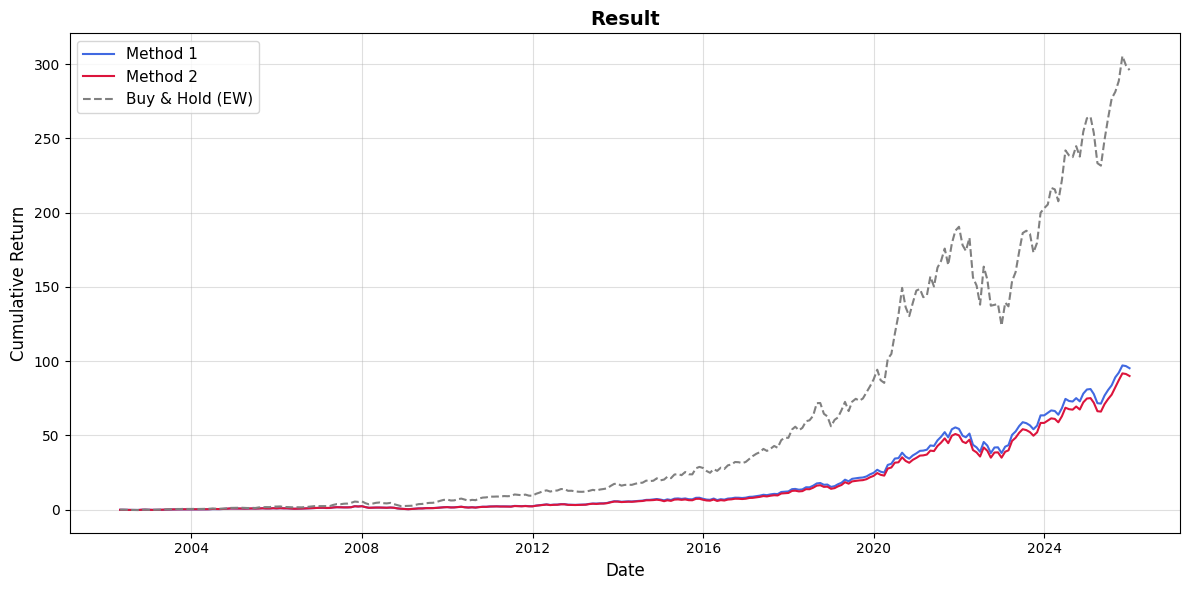

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

port_returns_m1 = []
port_returns_m2 = []
port_returns_bh = [] # Buy and Hold 수익률을 담을 리스트

num_assets = len(target_adj.columns)
# Buy and Hold (동일 비중) 가중치 설정
bh_weights = np.ones(num_assets) / num_assets 

# 앞서 구한 1월 말 비중에 2월 실제 수익률을 곱해 진짜 성과를 확인
for i in range(len(weights_method1_dynamic)):
    actual_returns = target_adj.iloc[window_size + i].values
    
    ret_m1 = np.dot(weights_method1_dynamic[i], actual_returns)
    ret_m2 = np.dot(weights_method2_static[i], actual_returns)
    ret_bh = np.dot(bh_weights, actual_returns) # Buy and Hold 수익률 계산
    
    port_returns_m1.append(ret_m1)
    port_returns_m2.append(ret_m2)
    port_returns_bh.append(ret_bh) # 리스트에 추가

port_returns_m1 = np.array(port_returns_m1)
port_returns_m2 = np.array(port_returns_m2)
port_returns_bh = np.array(port_returns_bh)

def calculate_metrics(returns, risk_free_rate=0.0):
    mean_ret = np.mean(returns)
    var_ret = np.var(returns)
    std_ret = np.std(returns)
    
    sharpe_ratio = (mean_ret - risk_free_rate) / std_ret if std_ret != 0 else 0
    
    cum_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - running_max) / running_max
    mdd = np.min(drawdowns)
    
    return mean_ret, var_ret, sharpe_ratio, mdd

mean1, var1, sharpe1, mdd1 = calculate_metrics(port_returns_m1)
mean2, var2, sharpe2, mdd2 = calculate_metrics(port_returns_m2)
mean_bh, var_bh, sharpe_bh, mdd_bh = calculate_metrics(port_returns_bh) # 벤치마크 지표 계산

metrics_df = pd.DataFrame({
    'Method 1': [mean1, var1, sharpe1, mdd1],
    'Method 2': [mean2, var2, sharpe2, mdd2],
    'Buy & Hold': [mean_bh, var_bh, sharpe_bh, mdd_bh] # 데이터프레임에 열 추가
}, index=['Mean Return', 'Variance', 'Sharpe Ratio', 'Max Drawdown (MDD)'])

print("=== 포트폴리오 성과 비교 ===")
print(metrics_df)

# X축 날짜 셋팅 (실제 수익률이 발생한 t+1 시점의 날짜들)
dates_eval = target_adj.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(dates_eval, np.cumprod(1 + port_returns_m1) - 1, label='Method 1', color='royalblue', linewidth=1.5)
plt.plot(dates_eval, np.cumprod(1 + port_returns_m2) - 1, label='Method 2', color='crimson', linewidth=1.5)
# 벤치마크 그래프 추가 (점선 처리하여 구분하기 쉽게 표현)
plt.plot(dates_eval, np.cumprod(1 + port_returns_bh) - 1, label='Buy & Hold (EW)', color='gray', linestyle='--', linewidth=1.5)

plt.title('Result', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Return', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

[Macro Time-Series] 총 수익률: 7497.12%, 샤프지수: 0.88, MDD: -57.34%
[Fund Time-Series]  총 수익률: 8261.68%, 샤프지수: 0.89, MDD: -57.27%
[Equal Weight]      총 수익률: 29592.85%, 샤프지수: 1.14, MDD: -48.31%


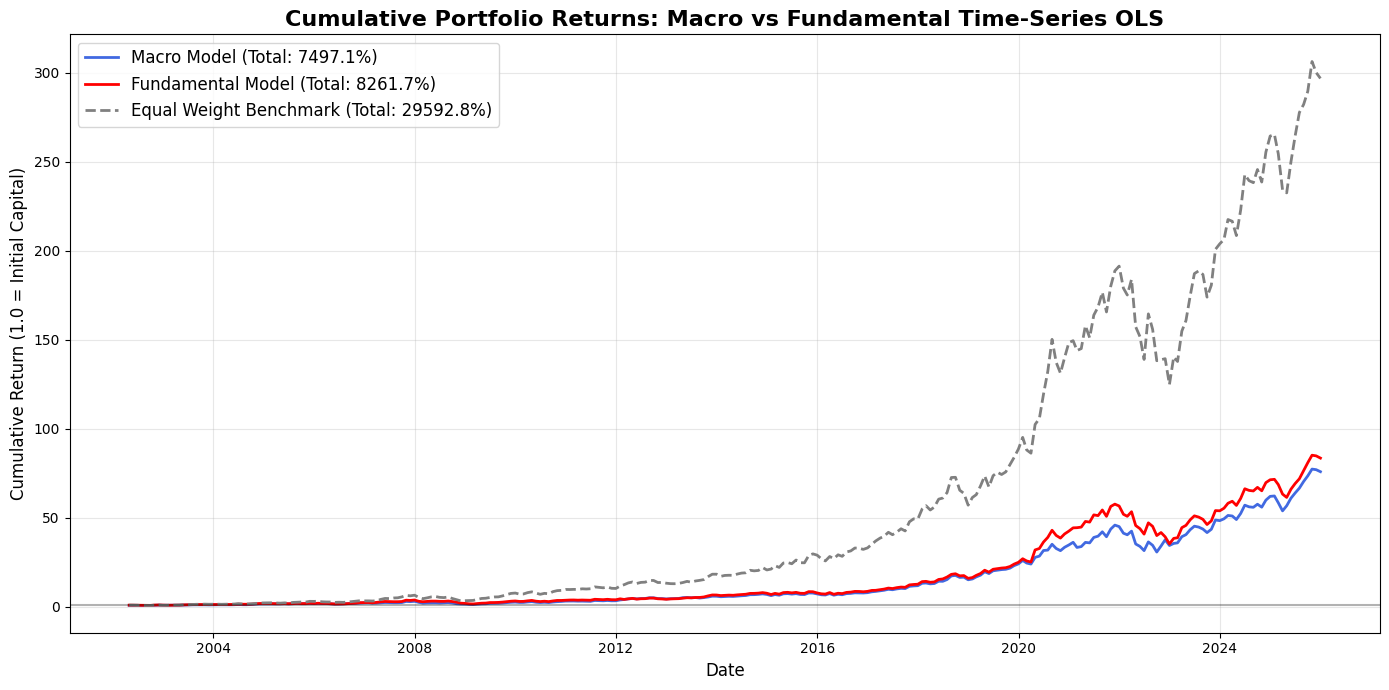

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 아웃오브샘플(OOS) 실제 수익률 데이터 추출
# 윈도우 사이즈 이후의 데이터가 실제 투자 성과를 측정할 구간입니다.
oos_returns = target_adj.iloc[window_size:]
oos_dates = oos_returns.index

# 2. 포트폴리오 수익률 계산
# (예측된 비중) * (실제 다음 달 수익률)의 합 = 포트폴리오 수익률
port_ret_macro = np.sum(np.array(weights_macro_ts) * oos_returns.values, axis=1)
port_ret_fund = np.sum(np.array(weights_fund_ts) * oos_returns.values, axis=1)

# 벤치마크: 동일 비중(Equal Weight) 포트폴리오 (예: 애플 1/3, 아마존 1/3, MSFT 1/3)
num_assets = len(target_adj.columns)
eq_weights = np.ones(num_assets) / num_assets
port_ret_eq = np.sum(eq_weights * oos_returns.values, axis=1)

# 3. 누적 수익률(Cumulative Returns) 계산
# 초기 자본금을 1(100%)로 가정하고 누적해서 곱해나감
cum_ret_macro = np.cumprod(1 + port_ret_macro)
cum_ret_fund = np.cumprod(1 + port_ret_fund)
cum_ret_eq = np.cumprod(1 + port_ret_eq)

# 4. 성과 지표(Metrics) 계산 함수 (MDD, Sharpe Ratio 등)
def calc_metrics(returns, risk_free_rate=0.0):
    returns_series = pd.Series(returns)
    cum_returns = (1 + returns_series).cumprod()
    
    # 총 수익률
    total_return = cum_returns.iloc[-1] - 1
    
    # 연율화 변동성 (월별 데이터이므로 sqrt(12) 곱함)
    ann_volatility = returns_series.std() * np.sqrt(12)
    
    # 연율화 샤프 지수
    ann_return = (1 + total_return) ** (12 / len(returns_series)) - 1
    sharpe_ratio = (ann_return - risk_free_rate) / ann_volatility if ann_volatility != 0 else 0
    
    # 최대 낙폭 (MDD)
    rolling_max = cum_returns.cummax()
    drawdown = (cum_returns - rolling_max) / rolling_max
    mdd = drawdown.min()
    
    return total_return, sharpe_ratio, mdd

# 각 전략별 성과 지표 계산
metrics_macro = calc_metrics(port_ret_macro)
metrics_fund = calc_metrics(port_ret_fund)
metrics_eq = calc_metrics(port_ret_eq)

print(f"[Macro Time-Series] 총 수익률: {metrics_macro[0]:.2%}, 샤프지수: {metrics_macro[1]:.2f}, MDD: {metrics_macro[2]:.2%}")
print(f"[Fund Time-Series]  총 수익률: {metrics_fund[0]:.2%}, 샤프지수: {metrics_fund[1]:.2f}, MDD: {metrics_fund[2]:.2%}")
print(f"[Equal Weight]      총 수익률: {metrics_eq[0]:.2%}, 샤프지수: {metrics_eq[1]:.2f}, MDD: {metrics_eq[2]:.2%}")

# 5. 시각화 (그래프 그리기)
plt.figure(figsize=(14, 7))

# 누적 수익률 선 그래프
plt.plot(oos_dates, cum_ret_macro, label=f'Macro Model (Total: {metrics_macro[0]:.1%})', color='royalblue', linewidth=2)
plt.plot(oos_dates, cum_ret_fund, label=f'Fundamental Model (Total: {metrics_fund[0]:.1%})', color='red', linewidth=2)
plt.plot(oos_dates, cum_ret_eq, label=f'Equal Weight Benchmark (Total: {metrics_eq[0]:.1%})', color='gray', linestyle='--', linewidth=2)

# 기준선(초기 자본 1.0)
plt.axhline(1.0, color='black', linestyle='-', alpha=0.3)

plt.title('Cumulative Portfolio Returns: Macro vs Fundamental Time-Series OLS', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (1.0 = Initial Capital)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [113]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg

weights_method1_dynamic = []
weights_method2_static = []
weights_macro_ts = [] # 3. 거시 요인 시계열 (ARX)
weights_fund_ts = []  # 4. 펀더멘털 시계열 (ARX)

for i in range(len(target_adj) - window_size):
    start_index = i
    end_index = i + window_size
    Y_window = target_adj.iloc[start_index:end_index]
    macro_window = macro_adj.iloc[start_index:end_index]
    fund_window = fund_adj.iloc[start_index:end_index]
    
    mu_m1 = []
    mu_m2 = []
    mu_macro_ts = []
    mu_fund_ts = []
    
    for col in target_adj.columns:
        y_col_rolled = Y_window[col]
        
        # ---------------------------------------------------------
        # [기존] Method 1 & 2 로직 (변화 없음)
        # ---------------------------------------------------------
        Y_train = y_col_rolled.iloc[1:]             
        X_macro_train_m1 = macro_window.iloc[:-1]      
        X_fund_train_m1 = fund_window.iloc[1:]        
        
        r2_m, _ = get_rsquared(Y_train, X_macro_train_m1)
        r2_f, _ = get_rsquared(Y_train, X_fund_train_m1)

        if r2_m > r2_f:
            model_m = sm.OLS(Y_train.values, sm.add_constant(X_macro_train_m1.values)).fit()
            latest_macro = macro_window.iloc[-1].values 
            next_macro_factor = np.insert(np.atleast_1d(latest_macro), 0, 1.0)
            pred_1 = model_m.predict(next_macro_factor)[0]
        else:
            model_f = sm.OLS(Y_train.values, sm.add_constant(X_fund_train_m1.values)).fit()
            betas = model_f.params
            expected_ff = fund_window.mean().values
            pred_1 = betas[0] + np.dot(betas[1:], expected_ff)
            
        mu_m1.append(pred_1) 
        
        model_no = sm.OLS(Y_train.values, sm.add_constant(X_fund_train_m1.values)).fit()
        betas_no = model_no.params
        expected_ff_no = fund_window.mean().values
        pred_2 = betas_no[0] + np.dot(betas_no[1:], expected_ff_no)
        
        mu_m2.append(pred_2)
        
        # ---------------------------------------------------------
        # [수정] Method 3 & 4: 정통 시계열 모형 (AutoReg) 적용
        # ---------------------------------------------------------
        # 시계열 전용 모델(AutoReg)은 내부적으로 lag를 처리해주므로 전체 데이터 셋팅
        y_ts = y_col_rolled.values
        x_macro_ts = macro_window.values
        x_fund_ts = fund_window.values
        
        try:
            # 3. 거시 요인 ARX 모형: lags=1은 자기 자신의 1기 과거를 봄, exog는 외생변수
            model_m_ts = AutoReg(endog=y_ts, lags=1, exog=x_macro_ts).fit()
            
            # 예측: 다음 1스텝(t+1)을 예측, 예측에 들어갈 최신 외생변수(exog_oos) 셋팅
            # AutoReg 모델은 가장 마지막에 있는 거시 데이터 하나를 넣어주면 알아서 1스텝 앞을 예측합니다.
            pred_m_ts = model_m_ts.predict(start=len(y_ts), end=len(y_ts), exog_oos=x_macro_ts[-1:])[0]
        except Exception as e:
            pred_m_ts = y_ts[-1] # 수렴 실패 시 직전 값으로 대체
            
        mu_macro_ts.append(pred_m_ts)
        
        try:
            # 4. 펀더멘털 요인 ARX 모형
            model_f_ts = AutoReg(endog=y_ts, lags=1, exog=x_fund_ts).fit()
            
            # 예측: t+1 스텝 예측
            pred_f_ts = model_f_ts.predict(start=len(y_ts), end=len(y_ts), exog_oos=x_fund_ts[-1:])[0]
        except Exception as e:
            pred_f_ts = y_ts[-1] # 수렴 실패 시 직전 값으로 대체
            
        mu_fund_ts.append(pred_f_ts)

    cov_matrix = Y_window.cov().values
    
    # 4가지 모델에 대한 마코위츠 MVO 수행
    w_m1 = get_optimal_weights(np.array(mu_m1), cov_matrix)
    w_m2 = get_optimal_weights(np.array(mu_m2), cov_matrix)
    w_m_ts = get_optimal_weights(np.array(mu_macro_ts), cov_matrix)
    w_f_ts = get_optimal_weights(np.array(mu_fund_ts), cov_matrix)
    
    weights_method1_dynamic.append(w_m1)
    weights_method2_static.append(w_m2)
    weights_macro_ts.append(w_m_ts)
    weights_fund_ts.append(w_f_ts)

In [117]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg

weights_method1_dynamic = []
weights_method2_static = []
weights_macro_ts = [] 
weights_fund_ts = []  

for i in range(len(target_adj) - window_size):
    # --- 현재 시점 설정 ---
    curr_idx = window_size + i
    
    # 1. 기존 모델용 데이터 (12개월 Rolling)
    Y_win_roll = target_adj.iloc[i : curr_idx]
    M_win_roll = macro_adj.iloc[i : curr_idx]
    F_win_roll = fund_adj.iloc[i : curr_idx]
    
    # 2. 시계열 모델용 데이터 (Expanding: 처음부터 현재 시점까지 전부)
    # 시계열 분석의 신뢰도를 위해 데이터를 길게 줍니다.
    Y_win_exp = target_adj.iloc[:curr_idx]
    M_win_exp = macro_adj.iloc[:curr_idx]
    F_win_exp = fund_adj.iloc[:curr_idx]
    
    mu_m1, mu_m2, mu_macro_ts, mu_fund_ts = [], [], [], []
    
    for col in target_adj.columns:
        # --- [Method 1 & 2] 기존 12개월 롤링 OLS ---
        y_roll = Y_win_roll[col]
        Y_tr_r = y_roll.iloc[1:]
        X_m_tr_r = M_win_roll.iloc[:-1]
        X_f_tr_r = F_win_roll.iloc[1:]
        
        r2_m, _ = get_rsquared(Y_tr_r, X_m_tr_r)
        r2_f, _ = get_rsquared(Y_tr_r, X_f_tr_r)
        
        if r2_m > r2_f:
            m_m = sm.OLS(Y_tr_r.values, sm.add_constant(X_m_tr_r.values)).fit()
            pred_1 = m_m.predict(np.insert(M_win_roll.iloc[-1].values, 0, 1.0))[0]
        else:
            m_f = sm.OLS(Y_tr_r.values, sm.add_constant(X_f_tr_r.values)).fit()
            pred_1 = m_f.params[0] + np.dot(m_f.params[1:], F_win_roll.mean().values)
        mu_m1.append(pred_1)
        
        m_no = sm.OLS(Y_tr_r.values, sm.add_constant(X_f_tr_r.values)).fit()
        mu_m2.append(m_no.params[0] + np.dot(m_no.params[1:], F_win_roll.mean().values))

        # --- [Method 3 & 4] 누적 시계열 ARX (Expanding Window) ---
        y_exp = Y_win_exp[col].values
        m_exp = M_win_exp.values
        f_exp = F_win_exp.values
        
        try:
            # Macro ARX: 누적된 긴 데이터를 사용하여 AR(1) 피팅
            res_m = AutoReg(y_exp, lags=1, exog=m_exp).fit()
            pred_m = res_m.predict(start=len(y_exp), end=len(y_exp), exog_oos=m_exp[-1:])[0]
            mu_macro_ts.append(pred_m)
            
            # Fund ARX: 누적된 긴 데이터를 사용하여 AR(1) 피팅
            res_f = AutoReg(y_exp, lags=1, exog=f_exp).fit()
            pred_f = res_f.predict(start=len(y_exp), end=len(y_exp), exog_oos=f_exp[-1:])[0]
            mu_fund_ts.append(pred_f)
        except:
            mu_macro_ts.append(y_exp[-1])
            mu_fund_ts.append(y_exp[-1])

    # 공분산은 최근 변동성을 반영해야 하므로 롤링 윈도우(12개월) 사용
    cov_mat = Y_win_roll.cov().values
    
    weights_method1_dynamic.append(get_optimal_weights(np.array(mu_m1), cov_mat))
    weights_method2_static.append(get_optimal_weights(np.array(mu_m2), cov_mat))
    weights_macro_ts.append(get_optimal_weights(np.array(mu_macro_ts), cov_mat))
    weights_fund_ts.append(get_optimal_weights(np.array(mu_fund_ts), cov_mat))

=== 포트폴리오 성과 비교 ===
                    Method 1  Method 2  Macro TS   Fund TS  Buy & Hold
Mean Return         0.018251  0.018064  0.021084  0.022670    0.022479
Variance            0.004233  0.004254  0.004542  0.004743    0.004658
Sharpe Ratio        0.280510  0.276980  0.312829  0.329176    0.329371
Max Drawdown (MDD) -0.600623 -0.603923 -0.517284 -0.394214   -0.483070


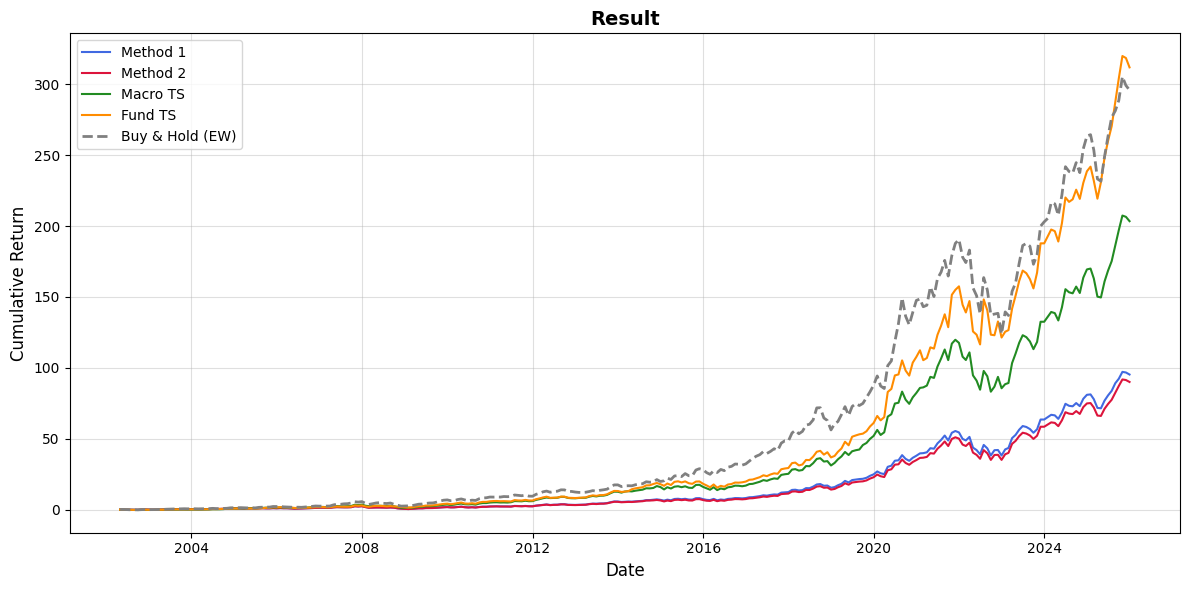

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

port_returns_m1 = []
port_returns_m2 = []
port_returns_m3 = [] # 거시 요인 시계열(Macro TS) 수익률
port_returns_m4 = [] # 펀더멘털 요인 시계열(Fund TS) 수익률
port_returns_bh = [] # Buy and Hold 수익률

num_assets = len(target_adj.columns)
# Buy and Hold (동일 비중) 가중치 설정
bh_weights = np.ones(num_assets) / num_assets 

# 앞서 구한 1월 말 비중에 2월 실제 수익률을 곱해 진짜 성과를 확인
for i in range(len(weights_method1_dynamic)):
    actual_returns = target_adj.iloc[window_size + i].values
    
    ret_m1 = np.dot(weights_method1_dynamic[i], actual_returns)
    ret_m2 = np.dot(weights_method2_static[i], actual_returns)
    ret_m3 = np.dot(weights_macro_ts[i], actual_returns) # Macro TS 적용
    ret_m4 = np.dot(weights_fund_ts[i], actual_returns)  # Fund TS 적용
    ret_bh = np.dot(bh_weights, actual_returns) 
    
    port_returns_m1.append(ret_m1)
    port_returns_m2.append(ret_m2)
    port_returns_m3.append(ret_m3)
    port_returns_m4.append(ret_m4)
    port_returns_bh.append(ret_bh)

port_returns_m1 = np.array(port_returns_m1)
port_returns_m2 = np.array(port_returns_m2)
port_returns_m3 = np.array(port_returns_m3)
port_returns_m4 = np.array(port_returns_m4)
port_returns_bh = np.array(port_returns_bh)

def calculate_metrics(returns, risk_free_rate=0.0):
    mean_ret = np.mean(returns)
    var_ret = np.var(returns)
    std_ret = np.std(returns)
    
    sharpe_ratio = (mean_ret - risk_free_rate) / std_ret if std_ret != 0 else 0
    
    cum_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - running_max) / running_max
    mdd = np.min(drawdowns)
    
    return mean_ret, var_ret, sharpe_ratio, mdd

# 각 방법론 지표 계산
mean1, var1, sharpe1, mdd1 = calculate_metrics(port_returns_m1)
mean2, var2, sharpe2, mdd2 = calculate_metrics(port_returns_m2)
mean3, var3, sharpe3, mdd3 = calculate_metrics(port_returns_m3)
mean4, var4, sharpe4, mdd4 = calculate_metrics(port_returns_m4)
mean_bh, var_bh, sharpe_bh, mdd_bh = calculate_metrics(port_returns_bh)

metrics_df = pd.DataFrame({
    'Method 1': [mean1, var1, sharpe1, mdd1],
    'Method 2': [mean2, var2, sharpe2, mdd2],
    'Macro TS': [mean3, var3, sharpe3, mdd3], # 추가
    'Fund TS': [mean4, var4, sharpe4, mdd4],   # 추가
    'Buy & Hold': [mean_bh, var_bh, sharpe_bh, mdd_bh]
}, index=['Mean Return', 'Variance', 'Sharpe Ratio', 'Max Drawdown (MDD)'])

print("=== 포트폴리오 성과 비교 ===")
print(metrics_df)

# X축 날짜 셋팅 (실제 수익률이 발생한 t+1 시점의 날짜들)
dates_eval = target_adj.index[window_size:]

plt.figure(figsize=(12, 6))
# 기존 모델
plt.plot(dates_eval, np.cumprod(1 + port_returns_m1) - 1, label='Method 1', color='royalblue', linewidth=1.5)
plt.plot(dates_eval, np.cumprod(1 + port_returns_m2) - 1, label='Method 2', color='crimson', linewidth=1.5)
# 시계열 모델 (색상 추가)
plt.plot(dates_eval, np.cumprod(1 + port_returns_m3) - 1, label='Macro TS', color='forestgreen', linewidth=1.5)
plt.plot(dates_eval, np.cumprod(1 + port_returns_m4) - 1, label='Fund TS', color='darkorange', linewidth=1.5)
# 벤치마크
plt.plot(dates_eval, np.cumprod(1 + port_returns_bh) - 1, label='Buy & Hold (EW)', color='gray', linestyle='--', linewidth=2)

plt.title('Result', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Return', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# 5요인

C:\Users\USER\AppData\Local\Temp\ipykernel_5480\2813212878.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5_data = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start_date, end_date)[0] / 100.0
C:\Users\USER\AppData\Local\Temp\ipykernel_5480\2813212878.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5_data = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start_date, end_date)[0] / 100.0
C:\Users\USER\AppData\Local\Temp\ipykernel_5480\2813212878.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  target_raw = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***

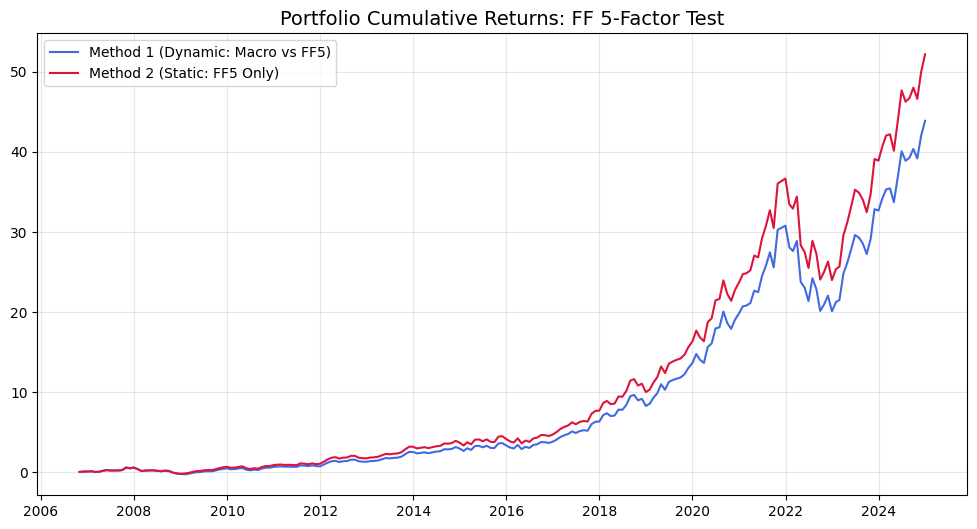

In [80]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pandas_datareader.data as web
import matplotlib.pyplot as plt

# 1. 데이터 설정 및 다운로드
start_date = "2005-01-01"
end_date = "2024-12-31"

# [펀더멘탈] Fama-French 5요인 데이터 (Mkt-RF, SMB, HML, RMW, CMA)
ff5_data = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start_date, end_date)[0] / 100.0
ff5_data.index = pd.to_datetime(ff5_data.index.astype(str)) + pd.offsets.MonthEnd(0)
fundamental_5f = ff5_data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
rf = ff5_data["RF"]

# [타겟 자산] 기존 노트북 예시 (AAPL, MSFT, AMZN)
tickers = ['AAPL', 'MSFT', 'AMZN']
target_raw = yf.download(tickers, start=start_date, end=end_date)['Close']
target_month = target_raw.resample('ME').last().pct_change().dropna()

# [매크로 요인] 기존 노트북 변수 (Oil, USD, Yield)
macro_tickers = ['CL=F', 'DX-Y.NYB', '^TNX']
macro_raw = yf.download(macro_tickers, start=start_date, end=end_date)['Close']
macro_month = macro_raw.resample('ME').last().dropna()
macro_returns = pd.DataFrame({
    'Oil': macro_month['CL=F'].pct_change(),
    'USD': macro_month['DX-Y.NYB'].pct_change(),
    'Yield': macro_month['^TNX'].diff()
}).dropna()

# 데이터 싱크 맞추기
common_idx = target_month.index.intersection(fundamental_5f.index).intersection(macro_returns.index)
target_adj = target_month.loc[common_idx]
fund_adj = fundamental_5f.loc[common_idx]
macro_adj = macro_returns.loc[common_idx]

# 2. 백테스트 루프 (FF 5요인 적용)
window_size = 20
weights_method1_dynamic = []
weights_method2_static = []

for i in range(len(target_adj) - window_size):
    start_index = i
    end_index = i + window_size
    
    Y_window = target_adj.iloc[start_index:end_index]
    macro_window = macro_adj.iloc[start_index:end_index]
    fund_window = fund_adj.iloc[start_index:end_index]
    
    mu_m1 = []
    mu_m2 = []
    
    for col in target_adj.columns:
        y_col_rolled = Y_window[col]
        Y_train = y_col_rolled.iloc[1:]             
        X_macro_train = macro_window.iloc[:-1]      
        X_fund_train = fund_window.iloc[1:]        
        
        # 설명력 비교: 매크로(3개) vs 펀더멘탈(5개)
        r2_m, _ = get_rsquared(Y_train, X_macro_train)
        r2_f, _ = get_rsquared(Y_train, X_fund_train)

        # 방법 1: Dynamic (더 높은 R2 모델 선택)
        if r2_m > r2_f:
            model_m = sm.OLS(Y_train.values, sm.add_constant(X_macro_train.values)).fit()
            latest_macro = macro_window.iloc[-1].values 
            next_factor = np.insert(np.atleast_1d(latest_macro), 0, 1.0)
            pred_1 = model_m.predict(next_factor)[0]
        else:
            model_f = sm.OLS(Y_train.values, sm.add_constant(X_fund_train.values)).fit()
            betas = model_f.params # [Alpha, Mkt, SMB, HML, RMW, CMA]
            expected_ff = fund_window.mean().values
            pred_1 = betas[0] + np.dot(betas[1:], expected_ff)
            
        mu_m1.append(pred_1) 
        
        # 방법 2: Static (FF 5요인 고정 사용)
        model_no = sm.OLS(Y_train.values, sm.add_constant(X_fund_train.values)).fit()
        betas_no = model_no.params
        expected_ff_no = fund_window.mean().values
        pred_2 = betas_no[0] + np.dot(betas_no[1:], expected_ff_no)
        mu_m2.append(pred_2)

    # 포트폴리오 최적화 (MVO)
    cov_matrix = Y_window.cov().values
    w_m1 = get_optimal_weights(np.array(mu_m1), cov_matrix)
    w_m2 = get_optimal_weights(np.array(mu_m2), cov_matrix)
    
    weights_method1_dynamic.append(w_m1)
    weights_method2_static.append(w_m2)

# 3. 결과 분석 및 시각화
dates_eval = target_adj.index[window_size:]
port_ret_m1 = []
port_ret_m2 = []

for i in range(len(weights_method1_dynamic)):
    actual = target_adj.iloc[window_size + i].values
    port_ret_m1.append(np.dot(weights_method1_dynamic[i], actual))
    port_ret_m2.append(np.dot(weights_method2_static[i], actual))

cum_m1 = (1 + pd.Series(port_ret_m1, index=dates_eval)).cumprod() - 1
cum_m2 = (1 + pd.Series(port_ret_m2, index=dates_eval)).cumprod() - 1

plt.figure(figsize=(12, 6))
plt.plot(cum_m1, label='Method 1 (Dynamic: Macro vs FF5)', color='royalblue')
plt.plot(cum_m2, label='Method 2 (Static: FF5 Only)', color='crimson')
plt.title('Portfolio Cumulative Returns: FF 5-Factor Test', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

=== 포트폴리오 성과 비교 ===
                    Method 1 (Dynamic)  Method 2 (Static)
Mean Return                   0.019612           0.020385
Variance                      0.004213           0.004180
Sharpe Ratio                  0.302136           0.315283
Max Drawdown (MDD)           -0.525786          -0.492926


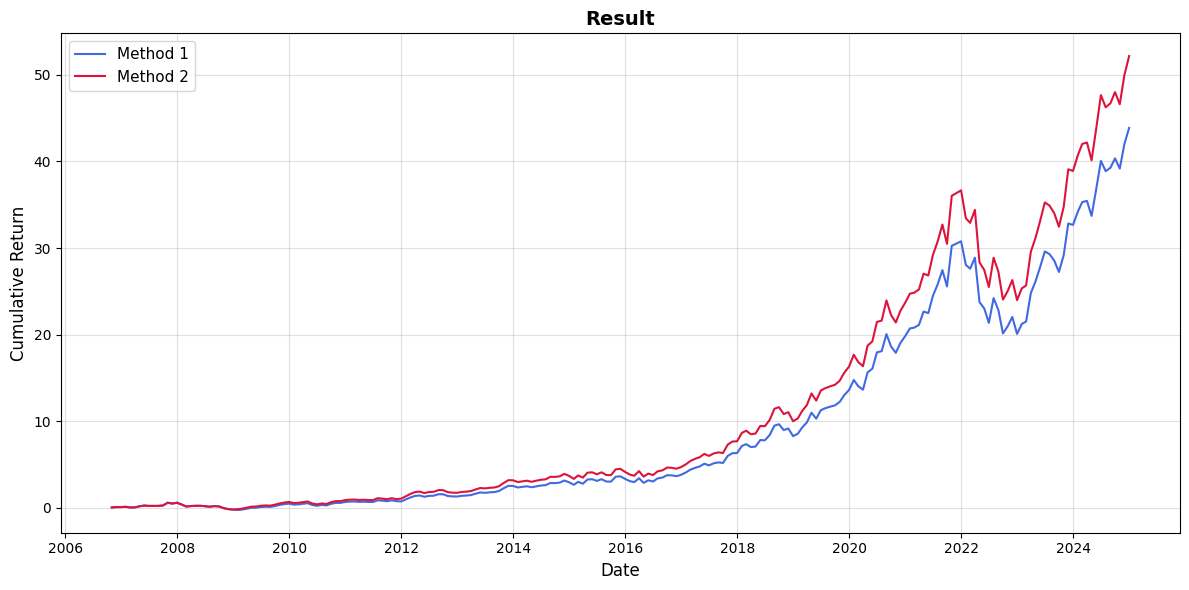

In [81]:
port_returns_m1 = []
port_returns_m2 = []

# 앞서 구한 1월 말 비중에 2월 실제 수익률을 곱해 진짜 성과를 확인
for i in range(len(weights_method1_dynamic)):
    actual_returns = target_adj.iloc[window_size + i].values
    
    ret_m1 = np.dot(weights_method1_dynamic[i], actual_returns)
    ret_m2 = np.dot(weights_method2_static[i], actual_returns)
    
    port_returns_m1.append(ret_m1)
    port_returns_m2.append(ret_m2)

port_returns_m1 = np.array(port_returns_m1)
port_returns_m2 = np.array(port_returns_m2)

def calculate_metrics(returns, risk_free_rate=0.0):
    mean_ret = np.mean(returns)
    var_ret = np.var(returns)
    std_ret = np.std(returns)
    
    sharpe_ratio = (mean_ret - risk_free_rate) / std_ret if std_ret != 0 else 0
    
    cum_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - running_max) / running_max
    mdd = np.min(drawdowns)
    
    return mean_ret, var_ret, sharpe_ratio, mdd

mean1, var1, sharpe1, mdd1 = calculate_metrics(port_returns_m1)
mean2, var2, sharpe2, mdd2 = calculate_metrics(port_returns_m2)

metrics_df = pd.DataFrame({
    'Method 1 (Dynamic)': [mean1, var1, sharpe1, mdd1],
    'Method 2 (Static)': [mean2, var2, sharpe2, mdd2]
}, index=['Mean Return', 'Variance', 'Sharpe Ratio', 'Max Drawdown (MDD)'])

print("=== 포트폴리오 성과 비교 ===")
print(metrics_df)

# X축 날짜 셋팅 (실제 수익률이 발생한 t+1 시점의 날짜들)
dates_eval = target_adj.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(dates_eval, np.cumprod(1 + port_returns_m1) - 1, label='Method 1', color='royalblue', linewidth=1.5)
plt.plot(dates_eval, np.cumprod(1 + port_returns_m2) - 1, label='Method 2', color='crimson', linewidth=1.5)

plt.title('Result', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Return', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# 요인 개수 비교

In [82]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
import pandas_datareader.data as web
from scipy.linalg import inv

# ==========================================
# 1. 데이터 수집 및 정제 (BMA용 매크로 데이터 제거)
# ==========================================
START, END = "2005-01-01", "2024-12-31"

def get_complete_data():
    print("📡 데이터를 수집 중입니다...")
    ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", START, END)[0] / 100.0
    mom = web.DataReader("F-F_Momentum_Factor", "famafrench", START, END)[0] / 100.0
    
    F = pd.concat([ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]], mom], axis=1).dropna()
    F.columns = ["Mkt", "SMB", "HML", "RMW", "CMA", "Mom"]
    RF = ff5["RF"]
    
    for df in [F, RF]: df.index = df.index.to_timestamp().to_period('M')
    common = F.index.intersection(RF.index)
    
    return [df.loc[common].to_timestamp(how='end').resample('ME').last().ffill().dropna() for df in [F, RF]]

F, RF = get_complete_data()

# ==========================================
# 2. 핵심 수학 엔진 (Static, AR1)
# ==========================================
def mv_weights(mu, cov, gamma=5.0):
    w = (1.0 / gamma) * inv(cov + np.eye(len(cov))*1e-6) @ mu
    w = np.maximum(w, 0.0) # 공매도 금지(Long-only) 조건
    return w / w.sum() if w.sum() > 1e-12 else np.ones_like(w)/len(w)

def get_static_forecast(train_f):
    """원래 요인 모형 (Static): 과거 평균 수익률을 미래 기대 수익률로 사용"""
    return train_f.mean().values

def get_ar1_forecast(train_f):
    """AR(1) 모형: 직전 과거 수익률의 추세를 반영하여 다음 기 수익률 예측"""
    return np.array([AutoReg(train_f[c].values, 1, trend='c').fit().forecast(1)[0] for c in train_f.columns])

def perf_stats(r, name):
    r = r.dropna()
    ann_ret = (1 + r).prod()**(12/len(r)) - 1
    ann_vol = r.std() * np.sqrt(12)
    sr = ann_ret / ann_vol
    mdd = ((1+r).cumprod() / (1+r).cumprod().cummax() - 1).min()
    return pd.Series([ann_ret, ann_vol, sr, mdd], index=['Return', 'Vol', 'Sharpe', 'MDD'], name=name)

# ==========================================
# 3. 백테스트 실행 (Static vs AR1)
# ==========================================
WINDOW = 60
dates = F.index
subsets = {
    "FF3": ["Mkt", "SMB", "HML"],
    "FF4": ["Mkt", "SMB", "HML", "Mom"],
    "FF5": ["Mkt", "SMB", "HML", "RMW", "CMA"],
    "FF6": ["Mkt", "SMB", "HML", "RMW", "CMA", "Mom"]
}

rets_dict = {"Market": []}
for k in subsets.keys():
    rets_dict[f"Static_{k}"] = []
    rets_dict[f"AR1_{k}"] = []

print("📈 [Static vs AR1] 백테스트 시작...")

for t in range(WINDOW, len(dates)):
    rf_next = float(RF.iloc[t])
    rets_dict["Market"].append(F["Mkt"].iloc[t] + rf_next)
    
    for name, cols in subsets.items():
        t_f = F[cols].iloc[t-WINDOW:t]
        f_next = F[cols].iloc[t].values
        cov = t_f.cov().values
        
        # 1. Static (단순 과거 평균)
        mu_static = get_static_forecast(t_f)
        rets_dict[f"Static_{name}"].append(rf_next + np.dot(mv_weights(mu_static, cov), f_next))
        
        # 2. AR1 (자기회귀 예측)
        mu_ar = get_ar1_forecast(t_f)
        rets_dict[f"AR1_{name}"].append(rf_next + np.dot(mv_weights(mu_ar, cov), f_next))

# ==========================================
# 4. 결과 출력
# ==========================================
res_df = pd.DataFrame(rets_dict, index=dates[WINDOW:])
summary = pd.concat([perf_stats(res_df[c], c) for c in res_df.columns], axis=1).T

print("\n=== 🏆 [Static vs AR1] 최종 성과 비교 ===")
print(summary.sort_values("Sharpe", ascending=False))

📡 데이터를 수집 중입니다...


C:\Users\USER\AppData\Local\Temp\ipykernel_5480\3167162748.py:16: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", START, END)[0] / 100.0
C:\Users\USER\AppData\Local\Temp\ipykernel_5480\3167162748.py:16: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", START, END)[0] / 100.0
C:\Users\USER\AppData\Local\Temp\ipykernel_5480\3167162748.py:17: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  mom = web.Dat

📈 [Static vs AR1] 백테스트 시작...

=== 🏆 [Static vs AR1] 최종 성과 비교 ===
              Return       Vol    Sharpe       MDD
AR1_FF6     0.060566  0.057394  1.055259 -0.078053
Static_FF6  0.052316  0.055171  0.948255 -0.099060
Static_FF4  0.091901  0.102254  0.898752 -0.148161
Market      0.135405  0.151111  0.896065 -0.248294
AR1_FF5     0.061267  0.069778  0.878025 -0.101354
Static_FF5  0.054653  0.064647  0.845404 -0.133424
AR1_FF4     0.074396  0.088352  0.842042 -0.127890
AR1_FF3     0.087979  0.118760  0.740817 -0.177654
Static_FF3  0.099488  0.134591  0.739187 -0.245447
